The purpose of this notebook is to make plotting functions and generate plots for the timeseries figure we will use as figure 2. May turn these functions into a script to generate plots automatically.

In [1]:
from hydra import compose, initialize
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import xarray as xr
import numpy as np
from pathlib import Path
from methane_noise_forcing import io
from methane_noise_forcing import detrend_obs
from methane_noise_forcing.naming import (
    generate_noise_realization_name,
    generate_firn_smoothing_name,
    generate_sample_name,
)
from scipy.stats import gaussian_kde

In [2]:
## figure settings
fig_width = 7 # inches
ax_height = 1.5 # inches
marker_darkness = 0.5  # 1.0 is tab:orange, <1 is darker
tab_orange_rgb = np.array(mcolors.to_rgb("tab:orange"))
darker_orange = tuple(tab_orange_rgb * marker_darkness)
plot_kwargs = {
    "obs": {
        "color": "k",
        "marker": "^",
        "linestyle": "None",
        "markersize": 5,
    },
    "instantaneous": {
        "color": "tab:blue",
        "linestyle": "-",
        "alpha": 0.5
    },
    "smoothed": {
        "color": "tab:orange",
        "linestyle": "-",
        "linewidth": 4,
        "alpha": 0.6
    },
    "sampled": {
        "marker": "^",
        "linestyle": "None",
        "markersize": 5,
        "markeredgecolor": "k",
        "markeredgewidth": 0.1,  # adjust thickness
        "color": darker_orange
    }
}

In [3]:
with initialize(version_base=None, config_path="../../configs"):
    cfg = compose(config_name="config")

# testing individual components

In [4]:
## functions

## load observational data

In [5]:
## parameters
site_name = 'wdc06a' # wdc05a, wdc06a, gisp2, neem
time_min = 800
time_max = 1800

In [6]:
## import data
data_obs = io.load_observational_data(site_name, **cfg.io[site_name].input)
# detrend data
data_obs_detrended = detrend_obs(site_name, data_obs)

# convert to dataset with 'ch4' and 'ch4_detrended'
data_obs = xr.Dataset(
    {
        "ch4": (["time"], data_obs.ch4),
        "ch4_detrended": (["time"], data_obs_detrended.ch4),
    },
    coords={
        "time": data_obs.gas_age
    }
)

# invert time axis
data_obs = data_obs.isel(time=slice(None, None, -1))

2025-08-22 18:03:57,431 - methane_noise_forcing.io - INFO - Loading WDC06A data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_wdc06a.csv
2025-08-22 18:03:57,441 - methane_noise_forcing.utils - INFO - Detrending data with polynomial of order 2


Text(0, 0.5, '')

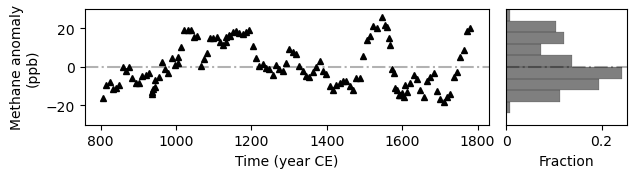

In [7]:
## plot obs data
time_slice = slice(time_min, time_max)
ylim = (-30, 30)

data_plot = data_obs["ch4_detrended"].sel(time=time_slice)

fig = plt.figure(figsize=(fig_width, 1 * ax_height))
gs = GridSpec(
    nrows=1,
    ncols=3,
    figure=fig,
    width_ratios=[1, 0, 0.3],
    wspace=0.05
)
ax_ts = fig.add_subplot(gs[0, 0]) # timeseries
ax_kd = fig.add_subplot(gs[0, 2]) # kernel density

ax_ts.plot(data_plot.time, data_plot, **plot_kwargs["obs"])
ax_ts.axhline(0, color="k", linestyle="-.", alpha=0.3)
ax_ts.set_xlabel("Time (year CE)")
ax_ts.set_ylabel("Methane anomaly\n(ppb)")
ax_ts.set_ylim(ylim)

# --- histogram on ax_kd ---
bin_min = ylim[0]  # tune as needed
bin_max = ylim[1]  # tune as needed
n_bins = 10        # tune as needed
bins = np.linspace(bin_min, bin_max, n_bins+1)
hist, bin_edges = np.histogram(data_plot, bins=bins)
hist_frac = hist / hist.sum()

# bin centers for plotting
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
ax_kd.barh(bin_centers, 
           hist_frac, 
           height=(bin_edges[1]-bin_edges[0]), 
           color="k", 
           alpha=0.5,
           edgecolor="k",
           linewidth=0.2)
ax_kd.axhline(0, color="k", linestyle="-.", alpha=0.3)

ax_kd.set_xlabel("Fraction")
ax_kd.set_xticks([0, 0.2])
ax_kd.set_xticklabels(["0", "0.2"])
ax_kd.set_ylim(ylim)
ax_kd.set_yticks([])
ax_kd.set_ylabel("")

## load instantaneous, smoothed, and sampled data from different timescales

In [8]:
timescales = [0.1, 1, 10, 100]

if (site_name == "wdc05a") or (site_name == "wdc06a"):
    filter_name = "wais"
else:
    filter_name = site_name

instantaneous_noise = {}
smoothed_noise = {}
sampled_noise = {}
for timescale in timescales:
    # resolve paths
    timescale_cfg = timescale
    if timescale == 0.1:
        timescale_cfg = "0-1"
    with initialize(version_base=None, config_path="../../configs"):
        cfg = compose(config_name="config", overrides=[
            f"+noise=two_timescale_ar1_{timescale_cfg}",
            f"+firn_kernel=firn_model_{filter_name}",
            f"+sampling={site_name}"
        ])
    noise_name = generate_noise_realization_name(cfg)
    firn_name = generate_firn_smoothing_name(cfg)
    sample_name = generate_sample_name(cfg)
    input_dir = Path(cfg.paths.noise_realizations_root)

    # load noise
    instantaneous_noise[timescale] = xr.load_dataset(input_dir / noise_name /  f"{noise_name}.nc")
    smoothed_noise[timescale] = xr.load_dataset(input_dir / noise_name / firn_name / f"smoothed_{noise_name}.nc")
    sampled_noise[timescale] = xr.load_dataset(input_dir / noise_name / firn_name / sample_name / f"sampled_smoothed_{noise_name}.nc")

    # invert time axis for sampled noise
    sampled_noise[timescale] = sampled_noise[timescale].isel(time=slice(None, None, -1))

    # re-center time axis for continuous noise representations to match sampling
    core_offset = sampled_noise[timescale].time.attrs["core_offset"]
    series_offset = sampled_noise[timescale].time.attrs["series_offset"]
    new_time = instantaneous_noise[timescale].time + core_offset - series_offset
    instantaneous_noise[timescale] = instantaneous_noise[timescale].assign_coords(time=new_time)
    smoothed_noise[timescale] = smoothed_noise[timescale].assign_coords(time=new_time)

Text(0.5, 0, 'Fraction')

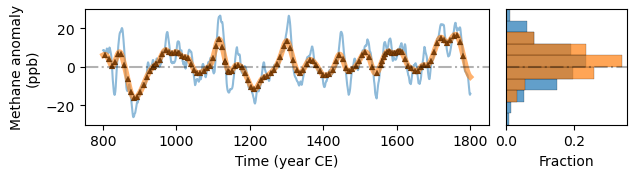

In [11]:
## sample plot for one timescale and one ensemble member
timescale = timescales[2]
idx_ens = 17
instantaneous_offset = 35 # years, amount to ADD to instantaneous time to synchronize with smoothed and sampled
# ylim = (-60, 60)
ylim = (-30, 30)

# slice data
time_slice = slice(time_min, time_max)
time_slice_instantaneous = slice(time_min - instantaneous_offset, time_max - instantaneous_offset)
instantaneous_plot = instantaneous_noise[timescale]["ch4"].isel(ensemble=idx_ens).sel(time=time_slice_instantaneous)
smoothed_plot = smoothed_noise[timescale]["ch4"].isel(ensemble=idx_ens).sel(time=time_slice)
sampled_plot = sampled_noise[timescale]["ch4"].isel(ensemble=idx_ens).sel(time=time_slice)

fig = plt.figure(figsize=(fig_width, 1 * ax_height))
gs = GridSpec(
    nrows=1,
    ncols=3,
    figure=fig,
    width_ratios=[1, 0, 0.3],
    wspace=0.05
)
ax_ts = fig.add_subplot(gs[0, 0]) # timeseries
ax_kd = fig.add_subplot(gs[0, 2]) # kernel density

# timeseries
ax_ts.plot(instantaneous_plot.time + instantaneous_offset, instantaneous_plot, **plot_kwargs["instantaneous"])
ax_ts.plot(smoothed_plot.time, smoothed_plot, **plot_kwargs["smoothed"])
ax_ts.plot(sampled_plot.time, sampled_plot, **plot_kwargs["sampled"])
ax_ts.axhline(0, color="k", linestyle="-.", alpha=0.3)
ax_ts.set_ylim(ylim)
ax_ts.set_xlabel("Time (year CE)")
ax_ts.set_ylabel("Methane anomaly\n(ppb)")

# --- histogram on ax_kd ---
bin_min = ylim[0]  # tune as needed
bin_max = ylim[1]  # tune as needed
n_bins = int((ylim[1] - ylim[0]) / 6)       # tune as needed
bins = np.linspace(bin_min, bin_max, n_bins+1)
hist_instantaneous, _ = np.histogram(instantaneous_plot, bins=bins)
hist_instantaneous = hist_instantaneous / hist_instantaneous.sum()
hist_sampled, bin_edges = np.histogram(sampled_plot, bins=bins)
hist_sampled = hist_sampled / hist_sampled.sum()

# bin centers for plotting
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
ax_kd.barh(bin_centers, 
           hist_instantaneous,
           height=(bin_edges[1]-bin_edges[0]),
           color="tab:blue",
           alpha=0.7,
           edgecolor="k",
           linewidth=0.2
)
ax_kd.barh(bin_centers, 
           hist_sampled, 
           height=(bin_edges[1]-bin_edges[0]), 
           color="tab:orange", 
           alpha=0.7,
           edgecolor="k",
           linewidth=0.2)
ax_kd.axhline(0, color="k", linestyle="-.", alpha=0.3)

# # KDE for instantaneous and smoothed
# kde_grid = np.linspace(ylim[0], ylim[1], n_bins)

# # instantaneous KDE
# inst_data = instantaneous_plot.values
# inst_kde = gaussian_kde(inst_data)
# inst_density = inst_kde(kde_grid)
# # scale KDE to match histogram max
# max_frac = hist_frac.max()
# # inst_density *= max_frac / inst_density.max()

# # smoothed KDE
# smooth_data = smoothed_plot.values
# smooth_kde = gaussian_kde(smooth_data)
# smooth_density = smooth_kde(kde_grid)
# # smooth_density *= max_frac / smooth_density.max()

# # plot KDEs as lines
# ax_kd.plot(inst_density, kde_grid, color=plot_kwargs["instantaneous"]["color"], alpha=0.7, linewidth=2, label="Instantaneous")
# ax_kd.plot(smooth_density, kde_grid, color=plot_kwargs["smoothed"]["color"], alpha=0.7, linewidth=2, label="Smoothed")

ax_kd.set_ylim(ylim)
ax_kd.set_yticks([])
ax_kd.set_ylabel("")
ax_kd.set_xlabel("Fraction")